In [1]:
!pip install torch torchvision pandas numpy matplotlib

In [2]:
import kagglehub
path = kagglehub.dataset_download("olafkrastovski/handwritten-digits-0-9")

100%|██████████| 66.7M/66.7M [00:00<00:00, 112MB/s]

Extracting files...


Check the range of numbers to predict

In [3]:
import os
(os.listdir(path))

['4', '2', '9', '1', '8', '0', '5', '6', '7', '3']

In [4]:
len(os.listdir(path))

10

In [5]:
os.path.join(path , '/4')

'/4'

View the Sample Image

In [6]:
import os


img_path = os.path.join(path, '6')


images = [f for f in os.listdir(img_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

print(f"Image path: {img_path}")
print(f"Number of images found: {len(images)}")


Image path: /root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2/6
Number of images found: 2121


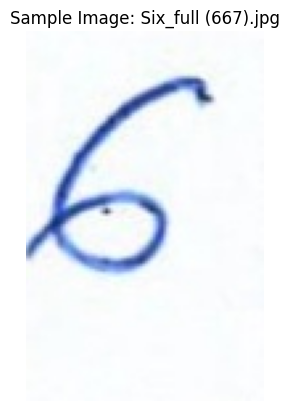

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

if images:
    # Construct the full path to a sample image (the first one in the list)
    sample_image_filename = images[0]
    full_image_path = os.path.join(img_path, sample_image_filename)

    # Open and display the image
    img = Image.open(full_image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Sample Image: {sample_image_filename}")
    plt.show()
else:
    print(f"No images found in the directory: {img_path}")

In [8]:
import os

digits_image_paths = {}



for digit_char in os.listdir(path):
    digit_folder_path = os.path.join(path, digit_char)
    if os.path.isdir(digit_folder_path):
        images_in_folder = [
            os.path.join(digit_folder_path, img_name)
            for img_name in os.listdir(digit_folder_path)
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        digits_image_paths[digit_char] = images_in_folder

print("Data structure created successfully!")
print(f"Number of digits found: {len(digits_image_paths)}")
print("Sample content (e.g., for digit '0'):")
if '0' in digits_image_paths:
    print(digits_image_paths['0'][:5])
else:
    print("Digit '0' not found in the dataset.")
print(digits_image_paths)

Data structure created successfully!
Number of digits found: 10
Sample content (e.g., for digit '0'):
['/root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2/0/Zero_full (760).jpg', '/root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2/0/Zero_full (1349).jpg', '/root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2/0/Zero_full (904).jpg', '/root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2/0/Zero_full (1996).jpg', '/root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2/0/Zero_full (275).jpg']
{'4': ['/root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2/4/Four_full (919).jpg', '/root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2/4/Four_full (609).jpg', '/root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2/4/Four_full (1067).jpg', '/root/.cache/kagglehub/datasets/olafkr

In [9]:
len(digits_image_paths)

10

In [10]:
import torch
import numpy as np
from PIL import Image

all_image_tensors = []
all_labels = []

for digit_char, image_paths_list in digits_image_paths.items():
    numerical_label = int(digit_char)

    for img_path in image_paths_list:
        try:
            # Open the image
            img = Image.open(img_path)

            # Convert to grayscale
            img = img.convert('L')

            # Resize the image to 28x28 pixels
            img = img.resize((28, 28))

            # Convert to a NumPy array
            img_array = np.array(img)

            # Normalize pixel values (0-1)
            normalized_array = img_array / 255.0

            # Convert to PyTorch tensor (float32)
            # Add a channel dimension for CNNs (28x28 becomes 1x28x28 for single channel)
            img_tensor = torch.tensor(normalized_array, dtype=torch.float32).unsqueeze(0)

            #  Append to lists
            all_image_tensors.append(img_tensor)
            all_labels.append(numerical_label)
        except Exception as e:
            print(f"Error processing image {img_path}: {e}")


if all_image_tensors and all_labels:
    X_tensor = torch.stack(all_image_tensors)
    y_tensor = torch.tensor(all_labels, dtype=torch.long)

    print(f"Dataset prepared successfully!")
    print(f"Shape of image tensor (X_tensor): {X_tensor.shape}")
    print(f"Shape of labels tensor (y_tensor): {y_tensor.shape}")
else:
    print("No images were processed. Check 'digits_image_paths' or image files.")

Dataset prepared successfully!
Shape of image tensor (X_tensor): torch.Size([21555, 1, 28, 28])
Shape of labels tensor (y_tensor): torch.Size([21555])


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: torch.Size([17244, 1, 28, 28])
Shape of X_test: torch.Size([4311, 1, 28, 28])
Shape of y_train: torch.Size([17244])
Shape of y_test: torch.Size([4311])


In [12]:
from torch.utils.data import TensorDataset


train_dataset = TensorDataset(X_train, y_train)

test_dataset = TensorDataset(X_test, y_test)

print(f"Length of train_dataset: {len(train_dataset)}")
print(f"Length of test_dataset: {len(test_dataset)}")

Length of train_dataset: 17244
Length of test_dataset: 4311


In [13]:
from torch.utils.data import DataLoader

batch_size = 64

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders created successfully!")
print(f"Number of batches in train_dataloader: {len(train_dataloader)}")
print(f"Number of batches in test_dataloader: {len(test_dataloader)}")

DataLoaders created successfully!
Number of batches in train_dataloader: 270
Number of batches in test_dataloader: 68


In [14]:
train_images_batch, train_labels_batch = next(iter(train_dataloader))
print(f"Shape of train_images_batch: {train_images_batch.shape}")
print(f"Shape of train_labels_batch: {train_labels_batch.shape}")

test_images_batch, test_labels_batch = next(iter(test_dataloader))
print(f"Shape of test_images_batch: {test_images_batch.shape}")
print(f"Shape of test_labels_batch: {test_labels_batch.shape}")

Shape of train_images_batch: torch.Size([64, 1, 28, 28])
Shape of train_labels_batch: torch.Size([64])
Shape of test_images_batch: torch.Size([64, 1, 28, 28])
Shape of test_labels_batch: torch.Size([64])


In [15]:
import torch.nn as nn
import torch.nn.functional as F

# Define the CNN architecture
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Input: 1 channel (grayscale), Output: 32 channels, Kernel size: 3x3, Padding: 1 (to maintain spatial dimensions)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)

        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)


        # Input: 32 channels, Output: 64 channels, Kernel size: 3x3, Padding: 1
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # Max pooling layer
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)




        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # conv -> relu -> pool
        x = self.pool1(F.relu(self.conv1(x)))

        x = self.pool2(F.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

print("CNN model architecture defined successfully.")

CNN model architecture defined successfully.


**Reasoning**:
The next step is to create an instance of the defined CNN model, which is necessary before training or evaluation. This allows us to inspect the model and prepare it for use.



In [16]:
model = CNN()
print("CNN model instantiated successfully:")
print(model)

CNN model instantiated successfully:
CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [17]:
import torch.optim as optim

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function (CrossEntropyLoss) and Optimizer (Adam) defined successfully.")

Loss function (CrossEntropyLoss) and Optimizer (Adam) defined successfully.


In [18]:
num_epochs = 10

for epoch in range(num_epochs):
    # Set the model to training mode
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for i, (images, labels) in enumerate(train_dataloader):
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_dataloader)
    train_accuracy = 100 * correct_train / total_train

    # Evaluate on test set
    model.eval() # Set the model to evaluation mode
    correct_test = 0
    total_test = 0
    test_loss = 0.0
    with torch.no_grad(): # Disable gradient calculation for evaluation
        for images, labels in test_dataloader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_loss /= len(test_dataloader)
    test_accuracy = 100 * correct_test / total_test

    print(f'Epoch [{epoch+1}/{num_epochs}], ')
    print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}% ')
    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')

print('\nTraining complete!')

Epoch [1/10], 
Train Loss: 1.6189, Train Accuracy: 45.49% 
Test Loss: 0.9880, Test Accuracy: 68.80%
Epoch [2/10], 
Train Loss: 0.6950, Train Accuracy: 78.55% 
Test Loss: 0.5184, Test Accuracy: 84.27%
Epoch [3/10], 
Train Loss: 0.4165, Train Accuracy: 87.50% 
Test Loss: 0.3586, Test Accuracy: 89.58%
Epoch [4/10], 
Train Loss: 0.3033, Train Accuracy: 90.95% 
Test Loss: 0.3082, Test Accuracy: 91.02%
Epoch [5/10], 
Train Loss: 0.2389, Train Accuracy: 92.89% 
Test Loss: 0.2259, Test Accuracy: 93.37%
Epoch [6/10], 
Train Loss: 0.1964, Train Accuracy: 94.31% 
Test Loss: 0.2223, Test Accuracy: 93.18%
Epoch [7/10], 
Train Loss: 0.1605, Train Accuracy: 95.07% 
Test Loss: 0.2006, Test Accuracy: 94.04%
Epoch [8/10], 
Train Loss: 0.1356, Train Accuracy: 95.94% 
Test Loss: 0.1800, Test Accuracy: 94.57%
Epoch [9/10], 
Train Loss: 0.1147, Train Accuracy: 96.68% 
Test Loss: 0.1702, Test Accuracy: 95.29%
Epoch [10/10], 
Train Loss: 0.0934, Train Accuracy: 97.40% 
Test Loss: 0.1514, Test Accuracy: 95.45%

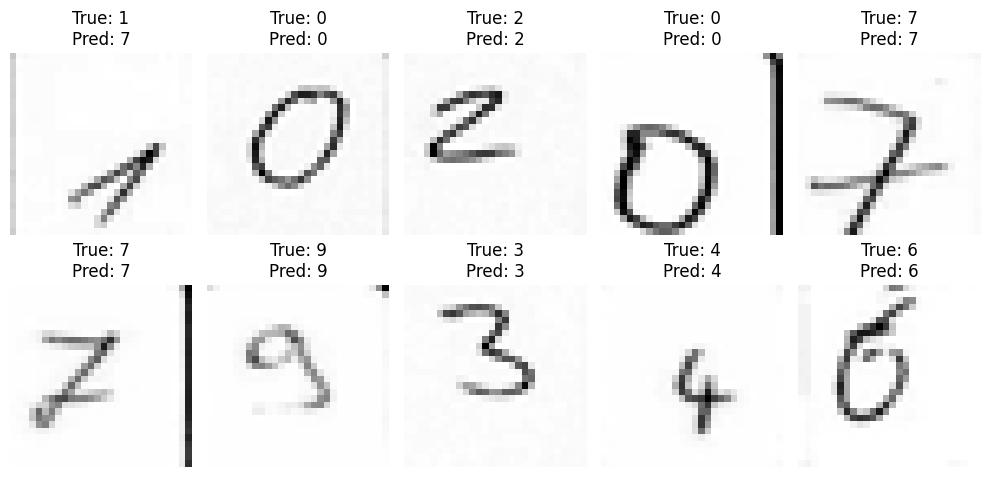

In [19]:
import matplotlib.pyplot as plt

# Set the model to evaluation mode
model.eval()


num_images_to_display = 10


images, labels = next(iter(test_dataloader))

# Make predictions
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)


fig = plt.figure(figsize=(10, 5))
for i in range(num_images_to_display):
    ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])

    img = images[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(f"True: {labels[i].item()}\nPred: {predicted[i].item()}")
    ax.axis('off')
plt.tight_layout()
plt.show()